In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance

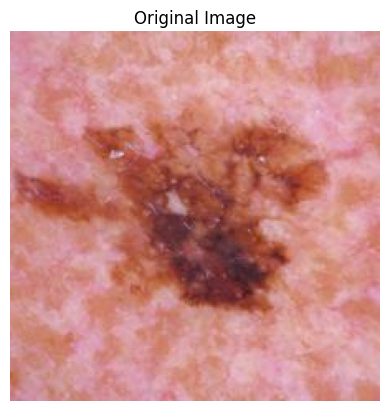

In [ ]:
img1 = Image.open("/content/drive/MyDrive/dataset_april_21/cropped blackedges/MEL/ISIC_0024310.jpg").convert("RGB")
plt.imshow(img1)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [ ]:
def random_rotation(image):
    angle = random.uniform( -12,12)

    import numpy as np
    img_array  = np.array(image)
    mean_color = tuple(img_array.mean(axis=(0, 1)).astype(int))

    return image.rotate(angle,resample=Image.BICUBIC,expand=False,fillcolor=mean_color)

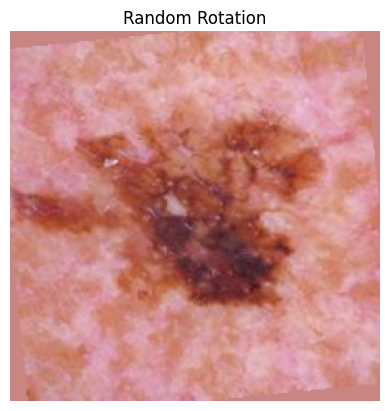

In [ ]:
rotated1=random_rotation(img1)
plt.imshow(rotated1)
plt.title("Random Rotation")
plt.axis("off")
plt.show()

In [ ]:
def fliped(image):
    import random
    from PIL import ImageOps

    if random.random() > 0.5:
        flipped = ImageOps.mirror(image)
    else:
        flipped = ImageOps.flip(image)

    return flipped

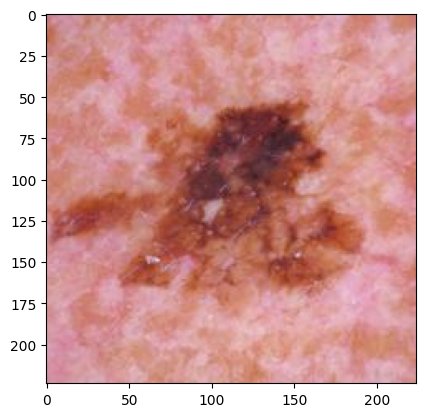

In [ ]:
flip=fliped(img1)
plt.imshow(flip)
plt.show()

In [ ]:
import random
from PIL import ImageEnhance

def brightness(image):

   if random.random() > 0.5:
        factor = random.uniform(0.7, 0.95)
   else:
        factor = random.uniform(1.05, 1.2)

   enhancer = ImageEnhance.Brightness(image)
   return enhancer.enhance(factor)



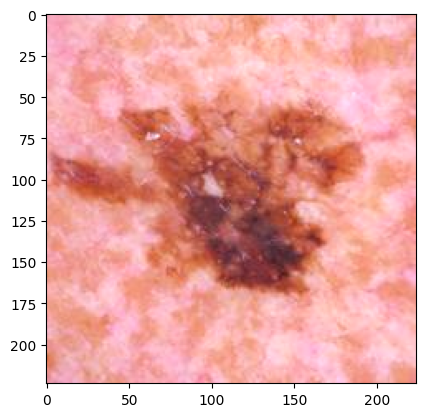

In [ ]:
bright = brightness(img1)
plt.imshow(bright)
plt.show()

In [ ]:
import random

def cropped(image):

    width, height = image.size
    scale = random.uniform(0.85, 0.95)
    new = int(width * scale)
    new = int(height * scale)
    left = random.randint(0, width - new)
    top = random.randint(0, height - new)
    right = left + new
    bottom = top + new
    cropped = image.crop((left, top, right, bottom))
    cropped = cropped.resize((width, height), Image.BICUBIC)
    return cropped

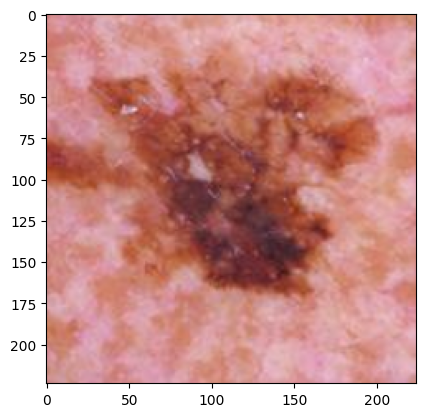

In [ ]:
crop = cropped(img1)
plt.imshow(crop)
plt.show()

splitting data before aug

In [ ]:
import os
import shutil
import random

input_base = "/content/drive/MyDrive/data_22_april/cropped"
output_base =  "/content/drive/MyDrive/data_22_april/split"
train_base = os.path.join(output_base, "Train")
test_base = os.path.join(output_base, "Test")

os.makedirs(train_base, exist_ok=True)
os.makedirs(test_base, exist_ok=True)

for class_name in os.listdir(input_base):
    class_path = os.path.join(input_base, class_name)
    if not os.path.isdir(class_path):
        continue
    images = os.listdir(class_path)

    random.shuffle(images)

    split_index = int(0.8 * len(images))
    train_images = images[:split_index]
    test_images = images[split_index:]

    train_class_path = os.path.join(train_base, class_name)
    test_class_path = os.path.join(test_base, class_name)

    os.makedirs(train_class_path, exist_ok=True)
    os.makedirs(test_class_path, exist_ok=True)

    for img_name in train_images:
        src = os.path.join(class_path, img_name)
        dst = os.path.join(train_class_path, img_name)
        shutil.copy(src, dst)

    for img_name in test_images:
        src = os.path.join(class_path, img_name)
        dst = os.path.join(test_class_path, img_name)
        shutil.copy(src, dst)

    print(f"{class_name} → Train: {len(train_images)}, Test: {len(test_images)}")

AKIEC → Train: 655, Test: 164
BCC → Train: 410, Test: 103
DF → Train: 184, Test: 47
BKL → Train: 875, Test: 219
VASC → Train: 202, Test: 51
MEL → Train: 881, Test: 221
NV → Train: 5220, Test: 1306


appy one variation of aug on train set

In [ ]:
import os
import random
from PIL import Image

train_base = "/content/drive/MyDrive/data_22_april/split/Train"
aug_base   = "/content/drive/MyDrive/data_22_april/PREPROCESSING/AUG"

augmentations = {
    "rotation":random_rotation,
    "crop": cropped,
    "brightness": brightness,
    "flip":fliped
}

for class_name in os.listdir(train_base):

    class_input_path = os.path.join(train_base, class_name)

    if not os.path.isdir(class_input_path):
        continue

    class_output_path = os.path.join(aug_base, class_name)
    os.makedirs(class_output_path, exist_ok=True)

    for img_name in os.listdir(class_input_path):

        img_path = os.path.join(class_input_path, img_name)

        try:
            image = Image.open(img_path).convert("RGB")
            name, ext = os.path.splitext(img_name)

            aug_name, aug_function = random.choice(list(augmentations.items()))

            augmented = aug_function(image)

            save_path = os.path.join(class_output_path, f"{name}_{aug_name}{ext}")
            augmented.save(save_path)

        except Exception as e:
            print(f"Error processing {img_name}: {e}")


combine train and aug data

In [ ]:
import os
import shutil

train_path = "/content/drive/MyDrive/data_22_april/split/Train"
aug_path = "/content/drive/MyDrive/data_22_april/PREPROCESSING/AUG"
combined_path = "/content/drive/MyDrive/data_22_april/PREPROCESSING/COMBINE(AUG+TRAIN)"

classes = ["AKIEC", "BCC", "BKL", "DF", "MEL", "NV", "VASC"]

for cls in classes:
    os.makedirs(os.path.join(combined_path, cls), exist_ok=True)


for cls in classes:
    src_folder = os.path.join(train_path, cls)
    dst_folder = os.path.join(combined_path, cls)

    for img in os.listdir(src_folder):
        src = os.path.join(src_folder, img)

        new_name = "train_" + img
        dst = os.path.join(dst_folder, new_name)

        shutil.copy(src, dst)


for aug_type in os.listdir(aug_path):

    aug_type_path = os.path.join(aug_path, aug_type)

    for cls in classes:
        src_folder = os.path.join(aug_type_path, cls)
        dst_folder = os.path.join(combined_path, cls)

        if not os.path.exists(src_folder):
            continue

        for img in os.listdir(src_folder):
            src = os.path.join(src_folder, img)

            new_name = f"{aug_type}_" + img
            dst = os.path.join(dst_folder, new_name)

            shutil.copy(src, dst)

print(" Combined successfully!")

✅ Combined successfully!


resize train set

In [ ]:
def resize_image(image, size=(224, 224)):
    return image.resize(size, Image.BICUBIC)

In [ ]:
import os
from PIL import Image

input_base ="/content/drive/MyDrive/data_22_april/split/Test"
output_base = "/content/drive/MyDrive/data_22_april/split/RESIZED_TESTDATA"


for class_name in os.listdir(input_base):

    input_class_path = os.path.join(input_base, class_name)
    output_class_path = os.path.join(output_base, class_name)

    os.makedirs(output_class_path, exist_ok=True)

    for img_name in os.listdir(input_class_path):
        img_path = os.path.join(input_class_path, img_name)

        try:

            image = Image.open(img_path).convert("RGB")
            resized =resize_image(image)
            save_path = os.path.join(output_class_path, img_name)
            resized.save(save_path)

        except Exception as e:
            print(f"Error processing {img_name}: {e}")